## DS 4420 - Proof of Concept (Data Pre-processing)

- Key Question: to what extent can a game's content, quality, and engagement metrics be used to predict its price on the Steam marketplace?" 

- File purpose: Pre-processing the data to save as a new CSV

- Date: 03/13

- Authors: Gianna Saw, Jason Zheng 


## Understanding our data

## 1. Load Raw Data

In [1]:
import pandas as pd 
import numpy as np
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt




In [2]:
ds = load_dataset("FronkonGames/steam-games-dataset")
raw = ds['train'].to_pandas()
print(raw.shape)
print(raw.columns.tolist())

(124146, 41)
['appID', 'name', 'release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'dlc_count', 'detailed_description', 'short_description', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots', 'movies', 'packages']


In [3]:
raw.head()

,appID,name,release_date,estimated_owners,peak_ccu,required_age,price,dlc_count,detailed_description,short_description,...,median_playtime_forever,median_playtime_2weeks,developers,publishers,categories,genres,tags,screenshots,movies,packages
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,,,...,0,0,[],[],[],[],[],[https://shared.akamai.steamstatic.com/store_i...,[],[]
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,0,"Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",...,8,0,[minori],[MangaGamer],"[Single-player, Steam Trading Cards, Steam Clo...",[Adventure],[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Supipara - Chapter 1 Spring Ha..."
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,"Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,...,0,0,[Somer Games],[8floor],"[Single-player, Family Sharing]",[Casual],[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Mystery Solitaire The Black Ra..."
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,...,0,0,[유진게임즈],[유진게임즈],"[Single-player, Steam Achievements, Family Sha...","[Casual, Indie, Simulation]",[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy \ubc84\ud29c\ubc84 \ud30c\ub77..."
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,[Reality Expanded LLC],[Reality Expanded LLC],"[Single-player, VR Only, Steam Leaderboards, F...","[Action, Early Access]",[],[https://shared.akamai.steamstatic.com/store_i...,[],"[{""title"": ""Buy Maze Quest VR"", ""description"":..."


In [4]:
print(raw.columns.tolist())

['appID', 'name', 'release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'dlc_count', 'detailed_description', 'short_description', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots', 'movies', 'packages']


#### Columns that we want to keep to match our RQ

- Target variable: 'price'
- Engagement metrics:
    - Peak CCU
    - Positive
    - Negative
    - Recommendations
    - Average playtime forever
    - Average playtime two weeks
    - Median playtime forever
    - Median playtime two weeks
    - Supported languages

- Quality metrics: 
    - Metacritic score
    - User score
    - Score rank

- Content features: 
    - Achievements
    - DiscountDLC count
    - Required age

- Platform support: 
    - Windows
    - Mac
    - Linux


## 2. Drop Irrelevant Columns 

In [5]:
drop_cols = [
    'name', 'release_date', 'detailed_description', 'short_description',
    'full_audio_languages', 'developers', 'publishers',
    'reviews', 'header_image', 'website', 'support_url',
    'support_email', 'metacritic_url', 'notes',
    'screenshots', 'movies', 'tags', 'score_rank', 'packages'
]
steam = raw.drop(columns=drop_cols)
print(f"After dropping: {steam.shape}")
steam.dtypes

After dropping: (124146, 22)


appID                        object
estimated_owners             object
peak_ccu                      int64
required_age                  int64
price                       float64
dlc_count                     int64
supported_languages          object
windows                        bool
mac                            bool
linux                          bool
metacritic_score              int64
user_score                    int64
positive                      int64
negative                      int64
achievements                  int64
recommendations               int64
average_playtime_forever      int64
average_playtime_2weeks       int64
median_playtime_forever       int64
median_playtime_2weeks        int64
categories                   object
genres                       object
dtype: object

## 3. Fix: Language Count

In [6]:
# printing the list type

print(type(steam['supported_languages'].iloc[1]))
print(repr(steam['supported_languages'].iloc[1]))

<class 'numpy.ndarray'>
array(['English'], dtype=object)


In [7]:
# Converting supported languages into numeric features
steam['language_count'] = steam['supported_languages'].apply(
    lambda x: len(x) if isinstance(x, np.ndarray) else 0
)

In [8]:
# running to see if it actually works 
steam['language_count'].head(3)

0    0
1    1
2    4
Name: language_count, dtype: int64

## 4. Fix: Estimated Owners
The column contains range strings like `"20000 - 50000"`.
We parse these by taking the midpoint, then log-transform later

In [9]:
# Parsing Estimated owners range strings into midpoint
steam['estimated_owners'] = steam['estimated_owners'].apply(
    lambda x: np.mean([int(p.replace(',', '').strip()) for p in x.split('-')]) if isinstance(x, str) else 0
)

In [10]:
# running to see if it actually works 
steam['estimated_owners'].head(3)

0        0.0
1    10000.0
2    10000.0
Name: estimated_owners, dtype: float64

## 5. Platform Columns (Boolean to Integer)

In [11]:
steam[['windows', 'mac', 'linux']] = steam[['windows', 'mac', 'linux']].apply(
    pd.to_numeric, errors='coerce').fillna(0).astype(int)

## 6. Sparsity Flags for Score Columns

Most games have no Metacritic or User score (stored as 0).
Adding binary flags so the model can distinguish "no score" from a real zero

In [12]:
steam['metacritic_score']

0         0
1         0
2         0
3         0
4         0
         ..
124141    0
124142    0
124143    0
124144    0
124145    0
Name: metacritic_score, Length: 124146, dtype: int64

In [13]:
# sparsity flags
steam['has_metacritic'] = (steam['metacritic_score'] > 0).astype(int)
steam['has_user_score'] = (steam['user_score'] > 0).astype(int)

print(f"Games with Metacritic score : {steam['has_metacritic'].sum():,}")
print(f"Games with User score       : {steam['has_user_score'].sum():,}")

Games with Metacritic score : 4,257
Games with User score       : 40


## 7. Genre & Category One-Hot Encoding

In [14]:
steam['genres']

0                                     []
1                            [Adventure]
2                               [Casual]
3            [Casual, Indie, Simulation]
4                 [Action, Early Access]
                       ...              
124141                          [Action]
124142    [Casual, Indie, RPG, Strategy]
124143        [Action, Adventure, Indie]
124144         [Casual, Indie, Strategy]
124145        [Action, Adventure, Indie]
Name: genres, Length: 124146, dtype: object

In [15]:
steam['categories']

0                                                        []
1         [Single-player, Steam Trading Cards, Steam Clo...
2                           [Single-player, Family Sharing]
3         [Single-player, Steam Achievements, Family Sha...
4         [Single-player, VR Only, Steam Leaderboards, F...
                                ...                        
124141    [Single-player, Steam Achievements, Full contr...
124142    [Single-player, Steam Achievements, Custom Vol...
124143                      [Single-player, Family Sharing]
124144    [Single-player, Steam Achievements, Custom Vol...
124145    [Single-player, Steam Achievements, Full contr...
Name: categories, Length: 124146, dtype: object

In [16]:
# Genres
genre_dummies = steam['genres'].explode().str.strip()
genre_dummies = pd.get_dummies(genre_dummies).groupby(level=0).max()
genre_dummies.columns = ['genre_' + c for c in genre_dummies.columns]


steam = steam.drop(columns=['genres'])
steam = pd.concat([steam, genre_dummies], axis=1)

In [17]:
steam

,appID,estimated_owners,peak_ccu,required_age,price,dlc_count,supported_languages,windows,mac,linux,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
0,2539430,0.0,0,0,0.00,0,[],1,0,0,...,False,False,False,False,False,False,False,False,False,False
1,496350,10000.0,0,0,5.24,0,[English],1,0,0,...,False,False,False,False,False,False,False,False,False,False
2,1034400,10000.0,0,0,4.99,0,"[English, French, German, Russian]",1,1,0,...,False,False,False,False,False,False,False,False,False,False
3,3292190,10000.0,1,0,8.99,1,[Korean],1,0,0,...,False,True,False,False,False,False,False,False,False,False
4,3631080,10000.0,0,0,4.99,0,[English],1,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124141,4123530,0.0,0,0,6.99,0,"[English, Simplified Chinese, Traditional Chin...",1,0,0,...,False,False,False,False,False,False,False,False,False,False
124142,4272850,0.0,0,0,3.99,0,"[English, Spanish - Spain]",1,0,0,...,False,False,False,False,True,False,False,False,False,False
124143,4302310,0.0,0,0,3.59,0,"[English, French, Italian, German, Spanish - S...",1,0,0,...,False,False,False,False,False,False,False,False,False,False
124144,4301980,0.0,0,0,2.99,0,"[English, French, Italian, German, Spanish - S...",1,0,0,...,False,False,False,False,True,False,False,False,False,False


## 8. Handle NaNs

In [18]:
print("NaN counts (top 10):")
print(steam.isnull().sum().sort_values(ascending=False).head(10))

# Fill remaining numeric NaNs with 0
steam = steam.fillna(0)

NaN counts (top 10):
appID                          0
genre_Audio Production         0
genre_Design & Illustration    0
genre_Documentary              0
genre_Early Access             0
genre_Education                0
genre_Episodic                 0
genre_Free To Play             0
genre_Game Development         0
genre_Gore                     0
dtype: int64


## 9. Log-Transform Skewed Columns

In [19]:
log_cols = ['peak_ccu', 'positive', 'negative', 'recommendations',
            'average_playtime_forever', 'average_playtime_2weeks',
            'median_playtime_forever', 'median_playtime_2weeks',
            'estimated_owners']

for col in log_cols:
    steam[col] = np.log1p(steam[col])

# Log-transform price
steam["price"] = np.log1p(steam["price"])

## 10. Filtering to paid games only

In [20]:
steam = steam[steam['price'] > 0]


## 11. Visualising target distributiom

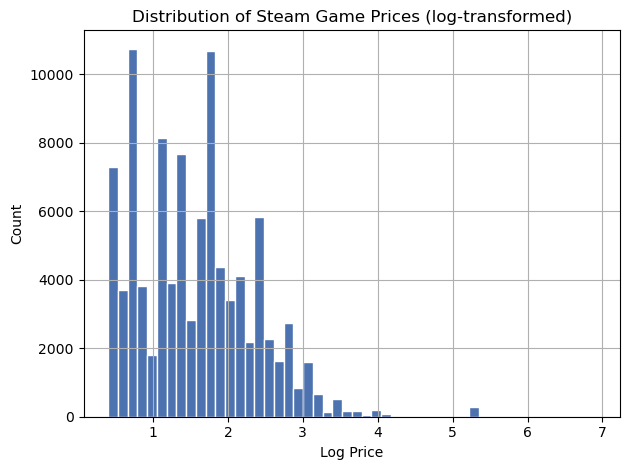

In [21]:
steam["price"].hist(bins=50, color="#4C72B0", edgecolor="white")
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.title("Distribution of Steam Game Prices (log-transformed)")
plt.tight_layout()
plt.show()

## 12. Final data checks

In [23]:
print(steam.shape)
print(steam.columns.tolist())
print(steam.head(3))

(97734, 57)
['appID', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'dlc_count', 'supported_languages', 'windows', 'mac', 'linux', 'metacritic_score', 'user_score', 'positive', 'negative', 'achievements', 'recommendations', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'categories', 'language_count', 'has_metacritic', 'has_user_score', 'genre_360 Video', 'genre_Accounting', 'genre_Action', 'genre_Adventure', 'genre_Animation & Modeling', 'genre_Audio Production', 'genre_Casual', 'genre_Design & Illustration', 'genre_Documentary', 'genre_Early Access', 'genre_Education', 'genre_Episodic', 'genre_Free To Play', 'genre_Game Development', 'genre_Gore', 'genre_Indie', 'genre_Massively Multiplayer', 'genre_Movie', 'genre_Nudity', 'genre_Photo Editing', 'genre_RPG', 'genre_Racing', 'genre_Sexual Content', 'genre_Short', 'genre_Simulation', 'genre_Software Training', 'genre_Sports', 'genre_Strategy', 'genre_Tutorial', 'ge

In [ ]:
# One hot encoding --> convert t/f into integers
genre_cols = [c for c in steam.columns if c.startswith('genre_')]
steam[genre_cols] = steam[genre_cols].astype(int)

In [26]:
steam

,appID,estimated_owners,peak_ccu,required_age,price,dlc_count,supported_languages,windows,mac,linux,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
1,496350,9.21044,0.000000,0,1.830980,0,[English],1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1034400,9.21044,0.000000,0,1.790091,0,"[English, French, German, Russian]",1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,3292190,9.21044,0.693147,0,2.301585,1,[Korean],1,0,0,...,0,1,0,0,0,0,0,0,0,0
4,3631080,9.21044,0.000000,0,1.790091,0,[English],1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1654170,9.21044,0.000000,0,2.707383,0,"[English, French, Italian, German, Spanish - S...",1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124141,4123530,0.00000,0.000000,0,2.078191,0,"[English, Simplified Chinese, Traditional Chin...",1,0,0,...,0,0,0,0,0,0,0,0,0,0
124142,4272850,0.00000,0.000000,0,1.607436,0,"[English, Spanish - Spain]",1,0,0,...,0,0,0,0,1,0,0,0,0,0
124143,4302310,0.00000,0.000000,0,1.523880,0,"[English, French, Italian, German, Spanish - S...",1,0,0,...,0,0,0,0,0,0,0,0,0,0
124144,4301980,0.00000,0.000000,0,1.383791,0,"[English, French, Italian, German, Spanish - S...",1,0,0,...,0,0,0,0,1,0,0,0,0,0


In [27]:
# Droppign uneeded cols
steam = steam.drop(columns=['supported_languages', 'categories', 'appID'])


In [28]:
steam

,estimated_owners,peak_ccu,required_age,price,dlc_count,windows,mac,linux,metacritic_score,user_score,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
1,9.21044,0.000000,0,1.830980,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9.21044,0.000000,0,1.790091,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9.21044,0.693147,0,2.301585,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,9.21044,0.000000,0,1.790091,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,9.21044,0.000000,0,2.707383,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124141,0.00000,0.000000,0,2.078191,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
124142,0.00000,0.000000,0,1.607436,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
124143,0.00000,0.000000,0,1.523880,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
124144,0.00000,0.000000,0,1.383791,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


## 13. Save cleaned CSV

In [29]:
steam.to_csv('steam_clean_v2.csv', index=False)